In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_PATH = "/kaggle/input/datasets/adityayellamilli/the-kvasircapsule-dataset-images/The Kvasir-Capsule"
TRAIN_IMG_PATH = os.path.join(BASE_PATH, "train")
TRAIN_CSV      = os.path.join(BASE_PATH, "Training_set.csv")

print("Base path exists:", os.path.exists(BASE_PATH))
print("Train folder exists:", os.path.exists(TRAIN_IMG_PATH))
print("CSV exists:", os.path.exists(TRAIN_CSV))

Base path exists: True
Train folder exists: True
CSV exists: True


In [3]:
df = pd.read_csv(TRAIN_CSV)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (37790, 2)

First 5 rows:


,filename,label
0,Image_1.jpg,Normal clean mucosa
1,Image_2.jpg,Normal clean mucosa
2,Image_3.jpg,Foreign body
3,Image_4.jpg,Normal clean mucosa
4,Image_5.jpg,Normal clean mucosa


In [4]:
print("Null values:\n", df.isnull().sum())
print("\nTotal unique classes:", df['label'].nunique())
print("\nClass names:")
for i,c in enumerate(df['label'].unique()):
    print("  ",i,":",c)

Null values:
 filename    0
label       0
dtype: int64

Total unique classes: 14

Class names:
   0 : Normal clean mucosa
   1 : Foreign body
   2 : Reduced mucosal view
   3 : Ileocecal valve
   4 : Lymphangiectasia
   5 : ulcer
   6 : Angiectasia
   7 : Pylorus
   8 : Erosion
   9 : Blood - fresh
   10 : Erythema
   11 : Polyp
   12 : ampulla_of_vater
   13 : Blood - hematin


In [5]:
class_counts = df['label'].value_counts().sort_values(ascending=False)

print("Class-wise Image Count:\n")
print(class_counts.to_string())
print(f"\nTotal images: {class_counts.sum()}")
print(f"Majority class: {class_counts.idxmax()} ({class_counts.max()} images)")
print(f"Minority class: {class_counts.idxmin()} ({class_counts.min()} images)")

Class-wise Image Count:

label
Normal clean mucosa     27470
Ileocecal valve          3351
Reduced mucosal view     2325
Pylorus                  1223
Angiectasia               693
ulcer                     683
Foreign body              621
Lymphangiectasia          473
Erosion                   405
Blood - fresh             357
Erythema                  127
Polyp                      44
Blood - hematin            10
ampulla_of_vater            8

Total images: 37790
Majority class: Normal clean mucosa (27470 images)
Minority class: ampulla_of_vater (8 images)


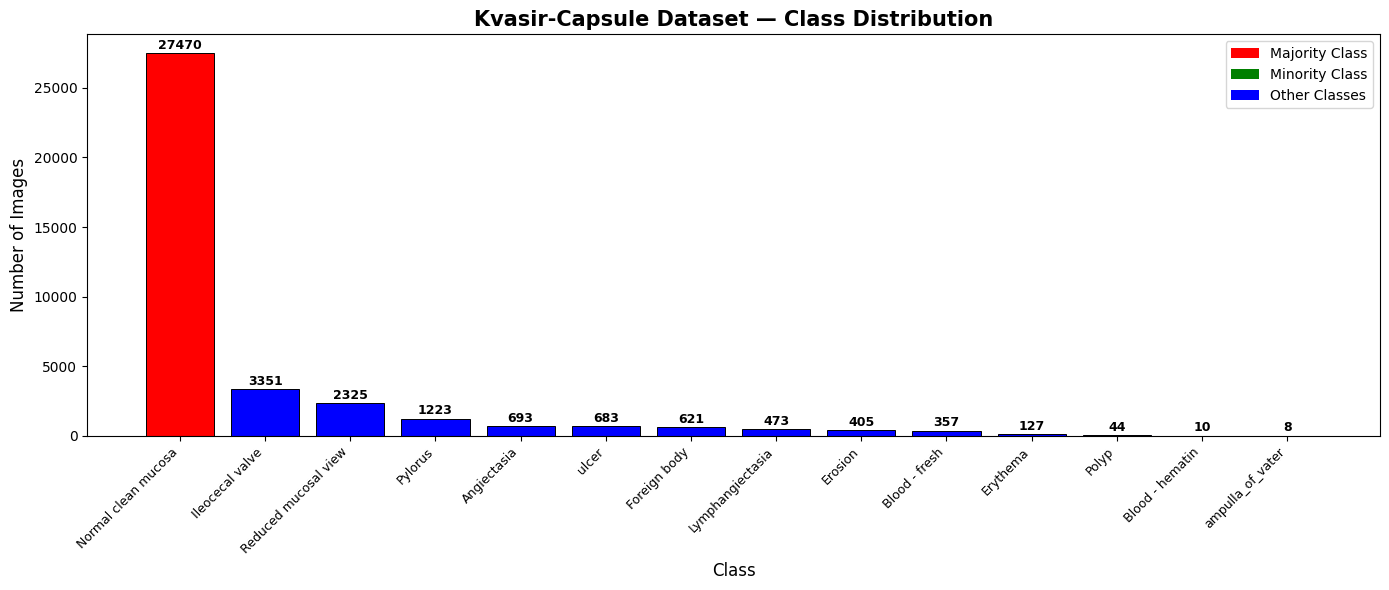

Plot saved as class_distribution.png


In [6]:
plt.figure(figsize=(14, 6))

colors = ['red' if c == class_counts.idxmax() 
          else 'green' if c == class_counts.idxmin() 
          else 'blue'
          for c in class_counts.index]

bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.7)

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Kvasir-Capsule Dataset — Class Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Majority Class'),
                   Patch(facecolor='green', label='Minority Class'),
                   Patch(facecolor='blue', label='Other Classes')]
plt.legend(handles=legend_elements, fontsize=10)

plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as class_distribution.png")

In [7]:
total = class_counts.sum()
imbalance_df = pd.DataFrame({
    'Class': class_counts.index,
    'Count': class_counts.values,
    'Percentage': (class_counts.values / total * 100).round(2),
    'Ratio vs Minority': (class_counts.values / class_counts.min()).round(1)
})

print(imbalance_df.to_string())

                   Class  Count  Percentage  Ratio vs Minority
0    Normal clean mucosa  27470       72.69             3433.8
1        Ileocecal valve   3351        8.87              418.9
2   Reduced mucosal view   2325        6.15              290.6
3                Pylorus   1223        3.24              152.9
4            Angiectasia    693        1.83               86.6
5                  ulcer    683        1.81               85.4
6           Foreign body    621        1.64               77.6
7       Lymphangiectasia    473        1.25               59.1
8                Erosion    405        1.07               50.6
9          Blood - fresh    357        0.94               44.6
10              Erythema    127        0.34               15.9
11                 Polyp     44        0.12                5.5
12       Blood - hematin     10        0.03                1.2
13      ampulla_of_vater      8        0.02                1.0


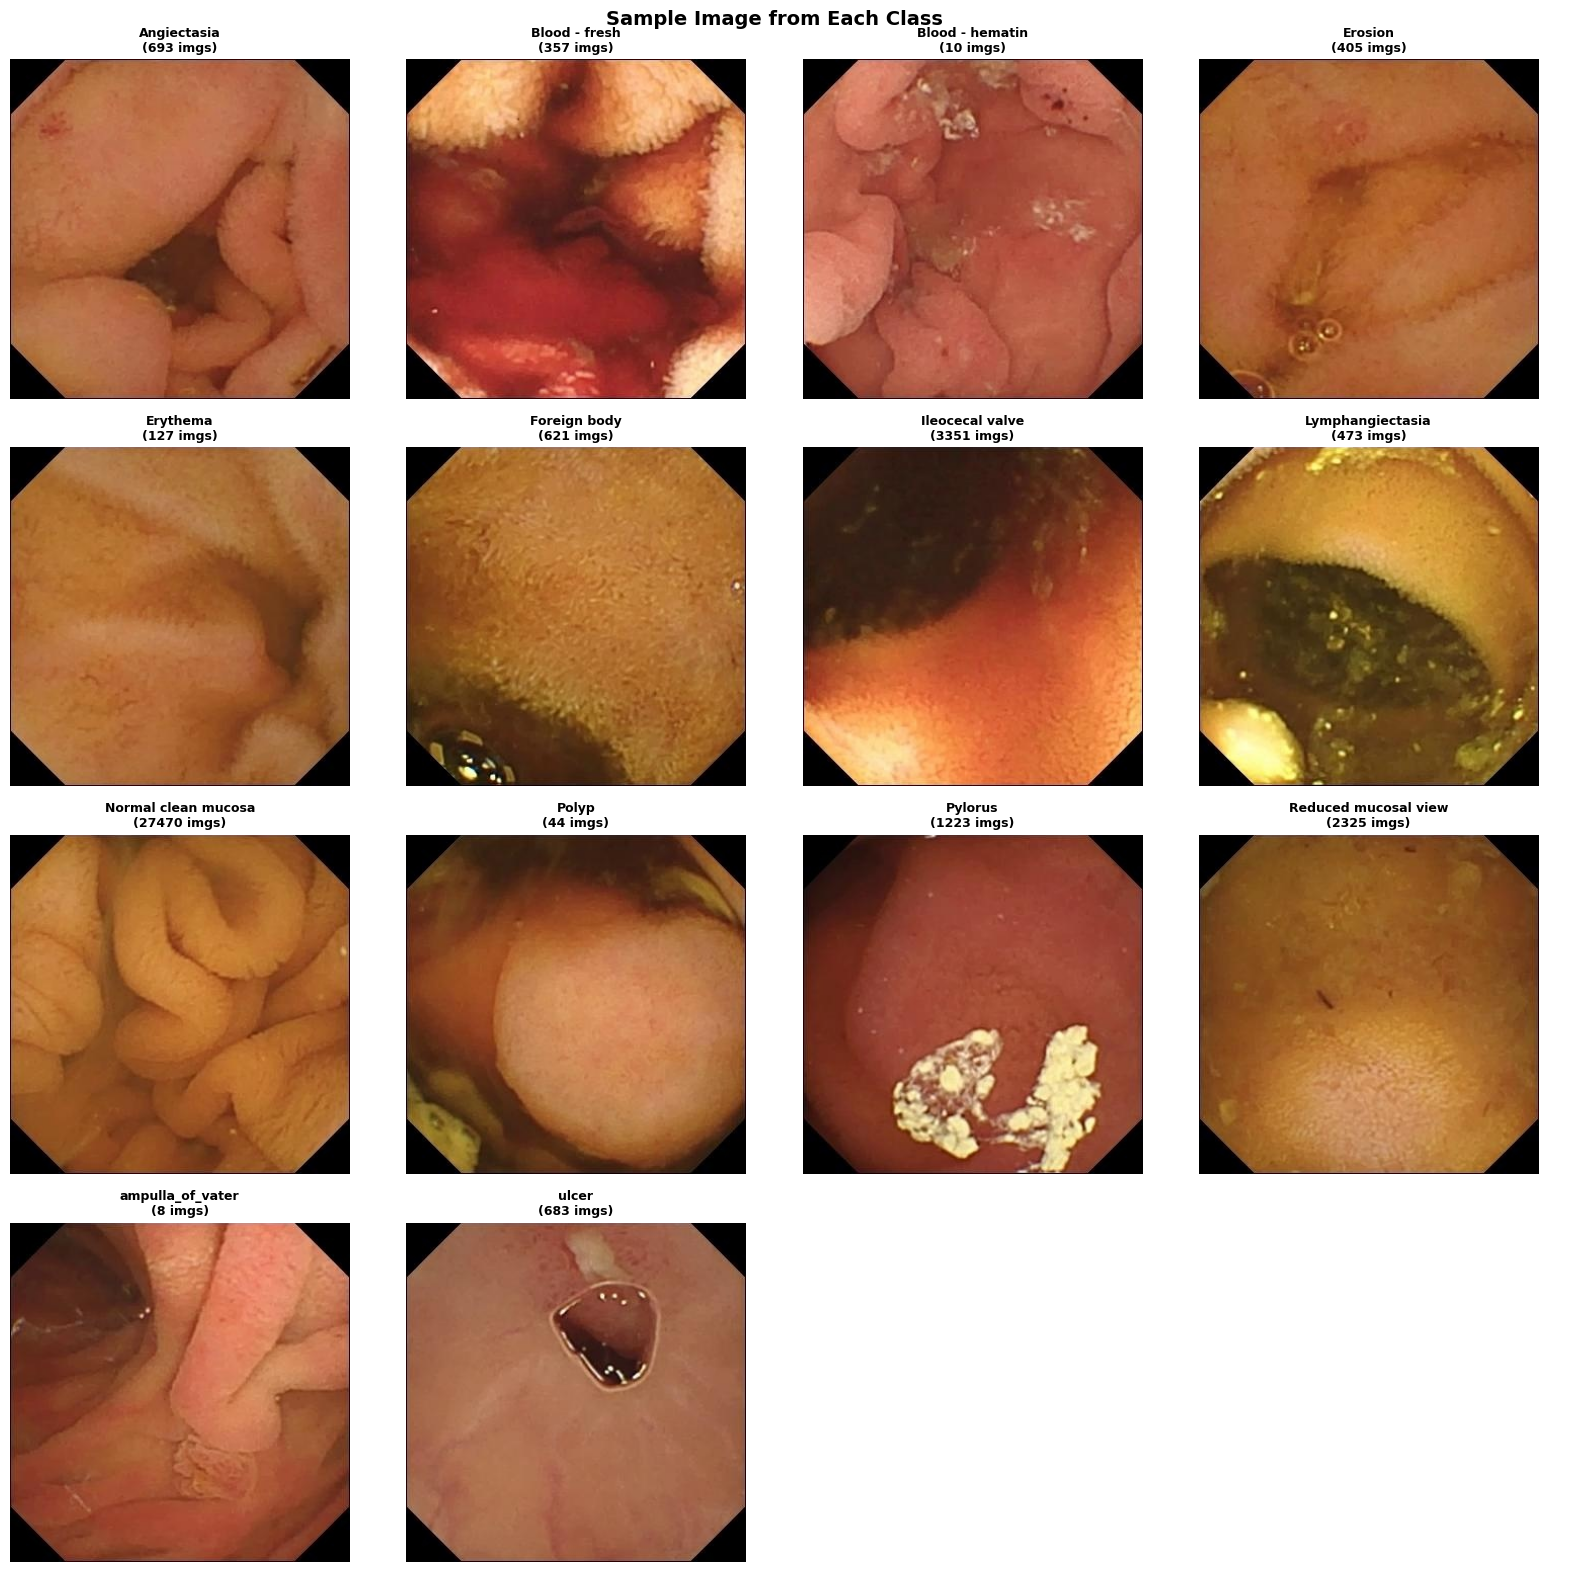

In [8]:
classes = sorted(df['label'].unique())
n = len(classes)

cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample = df[df['label'] == cls].iloc[0]['filename']
    img_path = os.path.join(TRAIN_IMG_PATH, sample)
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{cls}\n({class_counts[cls]} imgs)", fontsize=9, fontweight='bold')
        axes[i].axis('off')

# Hiding the unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle("Sample Image from Each Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images_per_class.png", dpi=150, bbox_inches='tight')
plt.show()

## Task 2

In [9]:
THRESHOLD = 200

print(f"Under-sampling threshold: {THRESHOLD} images/class")
print(f"Classes ABOVE threshold (will be reduced): ")
for cls, cnt in class_counts.items():
    if cnt > THRESHOLD:
        print(f"  {cls}: {cnt} → {THRESHOLD}")

print(f"\nClasses BELOW threshold (kept as-is): ")
for cls, cnt in class_counts.items():
    if cnt <= THRESHOLD:
        print(f"  {cls}: {cnt} → {cnt}")

Under-sampling threshold: 200 images/class
Classes ABOVE threshold (will be reduced): 
  Normal clean mucosa: 27470 → 200
  Ileocecal valve: 3351 → 200
  Reduced mucosal view: 2325 → 200
  Pylorus: 1223 → 200
  Angiectasia: 693 → 200
  ulcer: 683 → 200
  Foreign body: 621 → 200
  Lymphangiectasia: 473 → 200
  Erosion: 405 → 200
  Blood - fresh: 357 → 200

Classes BELOW threshold (kept as-is): 
  Erythema: 127 → 127
  Polyp: 44 → 44
  Blood - hematin: 10 → 10
  ampulla_of_vater: 8 → 8


In [10]:
undersampled_dfs = []

for cls in df['label'].unique():
    cls_df = df[df['label'] == cls]
    
    if len(cls_df) > THRESHOLD:
        # Randomly sample down to threshold
        cls_df = cls_df.sample(n=THRESHOLD, random_state=42)
    
    undersampled_dfs.append(cls_df)

df_undersampled = pd.concat(undersampled_dfs).reset_index(drop=True)

print(f"Original dataset size  : {len(df)}")
print(f"Undersampled dataset size: {len(df_undersampled)}")
print(f"Data removed           : {len(df) - len(df_undersampled)}")

Original dataset size  : 37790
Undersampled dataset size: 2189
Data removed           : 35601


In [11]:
new_counts = df_undersampled['label'].value_counts().sort_values(ascending=False)

print("Updated Class-wise Count:\n")
comparison = pd.DataFrame({
    'Class'    : class_counts.index,
    'Before'   : class_counts.values,
    'After'    : [new_counts.get(cls, 0) for cls in class_counts.index],
})
comparison['Removed'] = comparison['Before'] - comparison['After']
comparison = comparison.reset_index(drop=True)
comparison.index += 1
print(comparison.to_string())

Updated Class-wise Count:

                   Class  Before  After  Removed
1    Normal clean mucosa   27470    200    27270
2        Ileocecal valve    3351    200     3151
3   Reduced mucosal view    2325    200     2125
4                Pylorus    1223    200     1023
5            Angiectasia     693    200      493
6                  ulcer     683    200      483
7           Foreign body     621    200      421
8       Lymphangiectasia     473    200      273
9                Erosion     405    200      205
10         Blood - fresh     357    200      157
11              Erythema     127    127        0
12                 Polyp      44     44        0
13       Blood - hematin      10     10        0
14      ampulla_of_vater       8      8        0


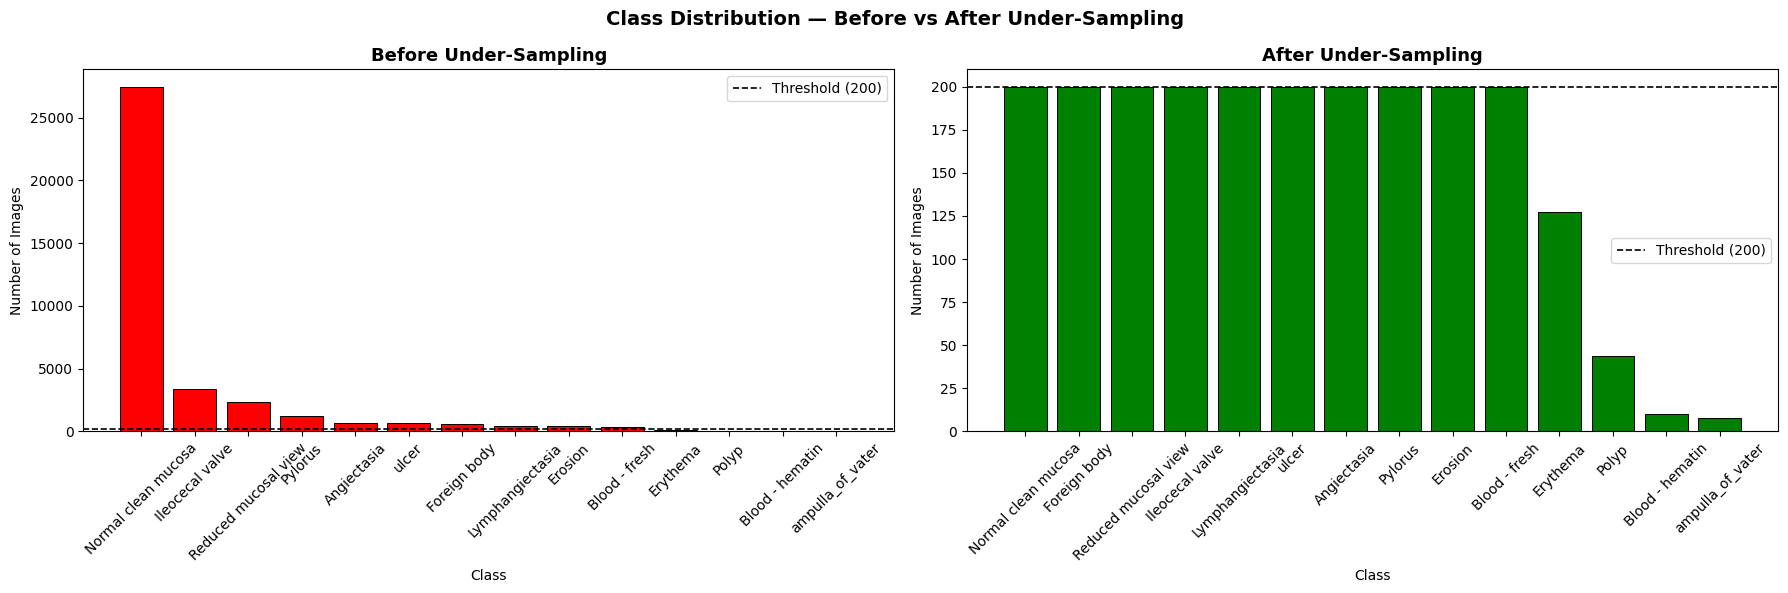

Plot saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Before ---
axes[0].bar(class_counts.index, class_counts.values, color='red', edgecolor='black', linewidth=0.7)
axes[0].set_title("Before Under-Sampling", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold ({THRESHOLD})')
axes[0].legend()

# --- After ---
colors_after = ['green' if v <= THRESHOLD else 'blue' for v in new_counts.values]
axes[1].bar(new_counts.index, new_counts.values, color=colors_after, edgecolor='black', linewidth=0.7)
axes[1].set_title("After Under-Sampling", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold ({THRESHOLD})')
axes[1].legend()

plt.suptitle("Class Distribution — Before vs After Under-Sampling", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("undersampling_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [13]:
df_undersampled.to_csv("df_undersampled.csv", index=False)
print("Saved df_undersampled.csv")
print(f"\nFinal undersampled dataset: {len(df_undersampled)} images across {df_undersampled['label'].nunique()} classes")

Saved df_undersampled.csv

Final undersampled dataset: 2189 images across 14 classes


## Task 3

In [14]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random

In [15]:
THRESHOLD      = 200
TRAIN_IMG_PATH = "/kaggle/input/datasets/adityayellamilli/the-kvasircapsule-dataset-images/The Kvasir-Capsule/train"
AUG_SAVE_PATH  = "/kaggle/working/augmented_images"
os.makedirs(AUG_SAVE_PATH, exist_ok=True)

df_undersampled = pd.read_csv("df_undersampled.csv")
class_counts    = df_undersampled['label'].value_counts()

minority_classes = class_counts[class_counts < THRESHOLD].index.tolist()
print("Classes needing augmentation:")
for cls in minority_classes:
    print(f"  {cls}: {class_counts[cls]} images → needs {THRESHOLD - class_counts[cls]} more")

Classes needing augmentation:
  Erythema: 127 images → needs 73 more
  Polyp: 44 images → needs 156 more
  Blood - hematin: 10 images → needs 190 more
  ampulla_of_vater: 8 images → needs 192 more


In [16]:
augment = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),  # width & height shift
        scale=(0.8, 1.2)       # zoom
    ),
    T.ColorJitter(brightness=0.2),
])

print("Augmentation pipeline defined:")
print(augment)

Augmentation pipeline defined:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.3)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.2, 0.2), scale=(0.8, 1.2))
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
)


In [17]:
augmented_records = []
random.seed(42)

for cls in minority_classes:
    cls_df        = df_undersampled[df_undersampled['label'] == cls]
    current_count = len(cls_df)
    needed        = THRESHOLD - current_count
    
    # Make save folder per class
    cls_save_dir = os.path.join(AUG_SAVE_PATH, cls.replace(" ", "_").replace("/", "-"))
    os.makedirs(cls_save_dir, exist_ok=True)
    
    print(f"\n[{cls}] — {current_count} original → generating {needed} augmented images...")
    
    # Cycle through original images to generate needed count
    source_files = cls_df['filename'].tolist()
    generated    = 0
    
    while generated < needed:
        src_filename = source_files[generated % len(source_files)]
        src_path     = os.path.join(TRAIN_IMG_PATH, src_filename)
        
        try:
            img        = Image.open(src_path).convert("RGB")
            aug_img    = augment(img)
            
            # Save augmented image
            aug_filename = f"aug_{cls.replace(' ', '_').replace('/', '-')}_{generated+1:04d}.jpg"
            aug_save_path = os.path.join(cls_save_dir, aug_filename)
            aug_img.save(aug_save_path, quality=95)
            
            augmented_records.append({
                'filename' : aug_save_path,  # full path since it's not in original train folder
                'label'    : cls,
                'augmented': True
            })
            generated += 1
            
        except Exception as e:
            print(f"  Error on {src_filename}: {e}")
            generated += 1  # skip and continue
    
    print(f"  Done — saved to {cls_save_dir}")

print("\nAll augmentation complete.")


[Erythema] — 127 original → generating 73 augmented images...
  Done — saved to /kaggle/working/augmented_images/Erythema

[Polyp] — 44 original → generating 156 augmented images...
  Done — saved to /kaggle/working/augmented_images/Polyp

[Blood - hematin] — 10 original → generating 190 augmented images...
  Done — saved to /kaggle/working/augmented_images/Blood_-_hematin

[ampulla_of_vater] — 8 original → generating 192 augmented images...
  Done — saved to /kaggle/working/augmented_images/ampulla_of_vater

All augmentation complete.


In [18]:
# Mark original images
df_original        = df_undersampled.copy()
df_original['augmented'] = False
# Add full path for original images too
df_original['filename'] = df_original['filename'].apply(
    lambda f: os.path.join(TRAIN_IMG_PATH, f)
)

# Augmented records
df_augmented = pd.DataFrame(augmented_records)

# Merge
df_final = pd.concat([df_original, df_augmented], ignore_index=True)

print(f"Original undersampled : {len(df_original)}")
print(f"Augmented added       : {len(df_augmented)}")
print(f"Final combined total  : {len(df_final)}")
print(f"\nNew class counts:")
print(df_final['label'].value_counts().sort_values(ascending=False).to_string())

Original undersampled : 2189
Augmented added       : 611
Final combined total  : 2800

New class counts:
label
Normal clean mucosa     200
Foreign body            200
Reduced mucosal view    200
Ileocecal valve         200
Lymphangiectasia        200
ulcer                   200
Angiectasia             200
Pylorus                 200
Erosion                 200
Blood - fresh           200
Erythema                200
Polyp                   200
ampulla_of_vater        200
Blood - hematin         200


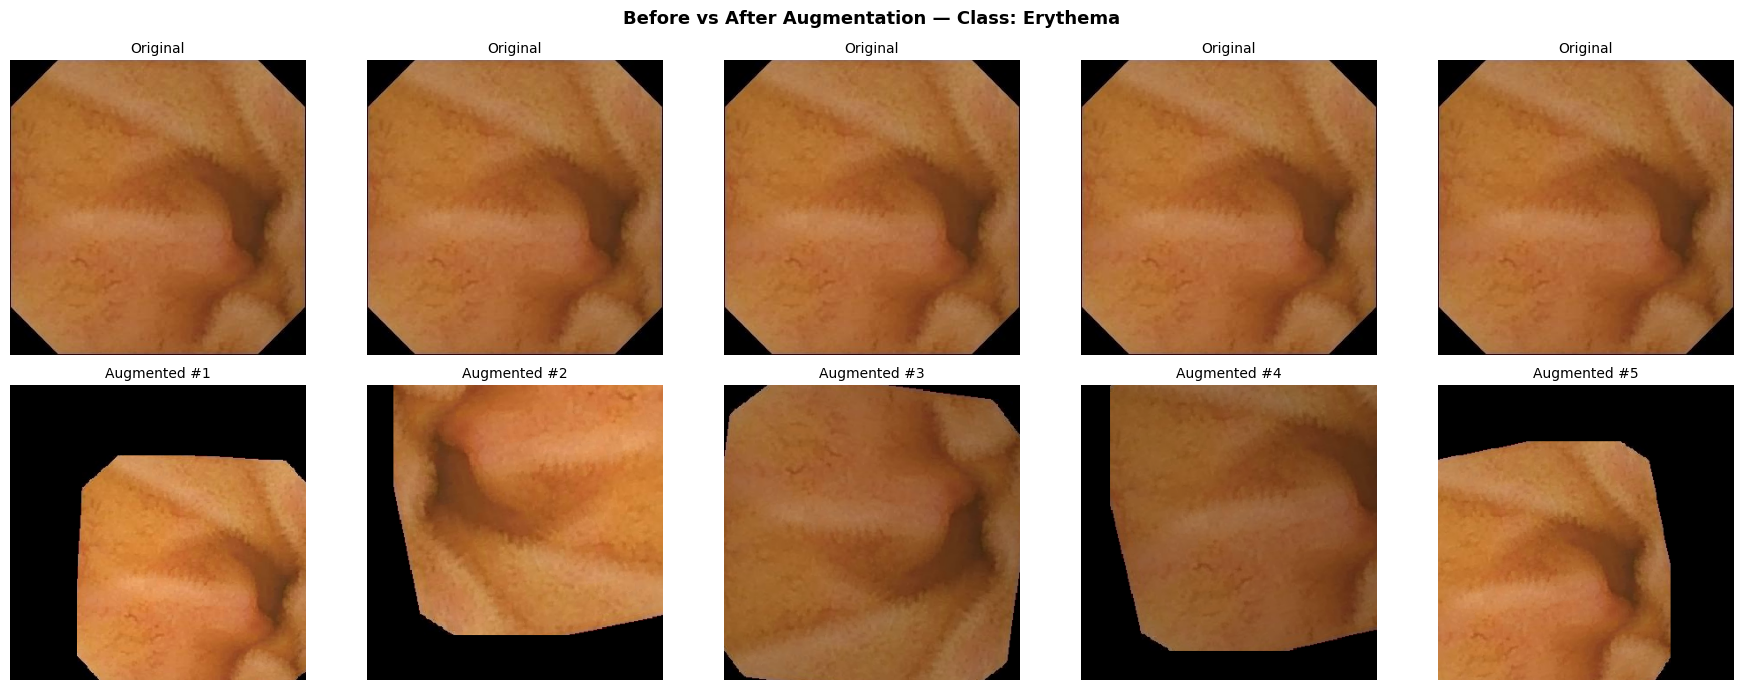

Saved augmentation_samples.png


In [19]:
# Pick one minority class to show before/after
demo_cls  = minority_classes[0]
demo_row  = df_undersampled[df_undersampled['label'] == demo_cls].iloc[0]
orig_path = os.path.join(TRAIN_IMG_PATH, demo_row['filename'])
orig_img  = Image.open(orig_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Top row — original (same image repeated)
for i in range(5):
    axes[0][i].imshow(orig_img)
    axes[0][i].set_title("Original", fontsize=10)
    axes[0][i].axis('off')

# Bottom row — 5 different augmentations
for i in range(5):
    aug_img = augment(orig_img)
    axes[1][i].imshow(aug_img)
    axes[1][i].set_title(f"Augmented #{i+1}", fontsize=10)
    axes[1][i].axis('off')

plt.suptitle(f"Before vs After Augmentation — Class: {demo_cls}", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("augmentation_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved augmentation_samples.png")

In [20]:
before_counts = df_undersampled['label'].value_counts()
after_counts  = df_final['label'].value_counts()

summary = pd.DataFrame({
    'Class'          : before_counts.index,
    'After Undersample': [before_counts.get(c, 0) for c in before_counts.index],
    'After Augment'  : [after_counts.get(c, 0) for c in before_counts.index],
    'Added'          : [after_counts.get(c, 0) - before_counts.get(c, 0) 
                        for c in before_counts.index]
}).reset_index(drop=True)
summary.index += 1

print("Dataset Size Summary:\n")
print(summary.to_string())
print(f"\nTotal before augmentation : {len(df_undersampled)}")
print(f"Total after augmentation  : {len(df_final)}")

Dataset Size Summary:

                   Class  After Undersample  After Augment  Added
1    Normal clean mucosa                200            200      0
2           Foreign body                200            200      0
3   Reduced mucosal view                200            200      0
4        Ileocecal valve                200            200      0
5       Lymphangiectasia                200            200      0
6                  ulcer                200            200      0
7            Angiectasia                200            200      0
8                Pylorus                200            200      0
9                Erosion                200            200      0
10         Blood - fresh                200            200      0
11              Erythema                127            200     73
12                 Polyp                 44            200    156
13       Blood - hematin                 10            200    190
14      ampulla_of_vater                  8          

In [21]:
df_final.to_csv("df_final_augmented.csv", index=False)
print("Saved df_final_augmented.csv")

Saved df_final_augmented.csv


In [22]:
import shutil

# Zip the entire augmented_images folder
shutil.make_archive(
    "/kaggle/working/augmented_images",
    'zip',
    "/kaggle/working",
    "augmented_images"
)

print("Created: /kaggle/working/augmented_images.zip")

# Check size
size = os.path.getsize("/kaggle/working/augmented_images.zip")
print(f"Zip size: {size / (1024*1024):.2f} MB")

Created: /kaggle/working/augmented_images.zip
Zip size: 13.46 MB
